In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('anime.csv')
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [5]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [6]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [7]:
df['genre']=df['genre'].fillna('Unknown')
df['type']=df['type'].fillna('Unknown')

In [8]:
df['rating']=df['rating'].fillna(df['rating'].median())
df['episodes']=pd.to_numeric(df['episodes'],errors='coerce').fillna(0)

In [9]:
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

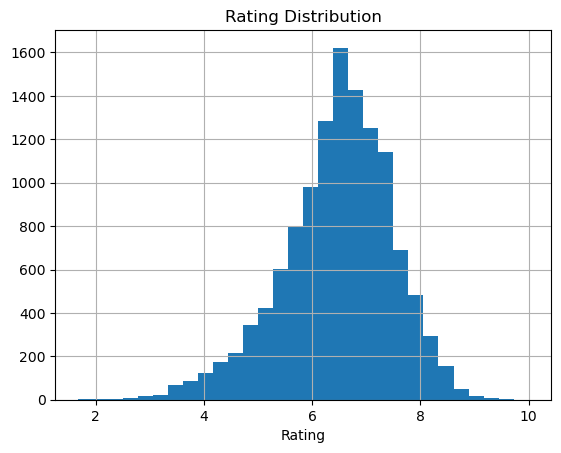

In [10]:
df['rating'].hist(bins=30)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.show()

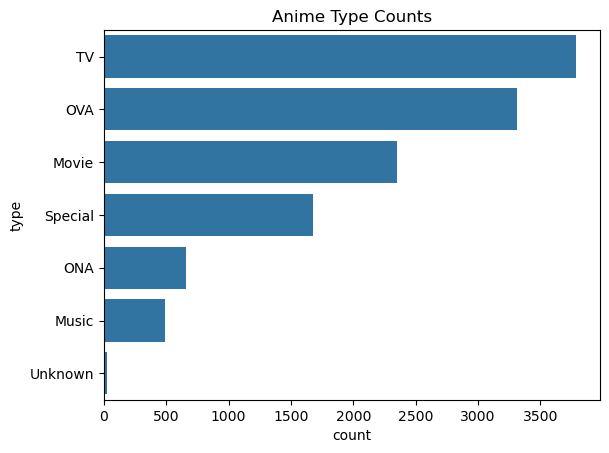

In [11]:
sns.countplot(y='type',data=df,order=df['type'].value_counts().index)
plt.title('Anime Type Counts')
plt.show()

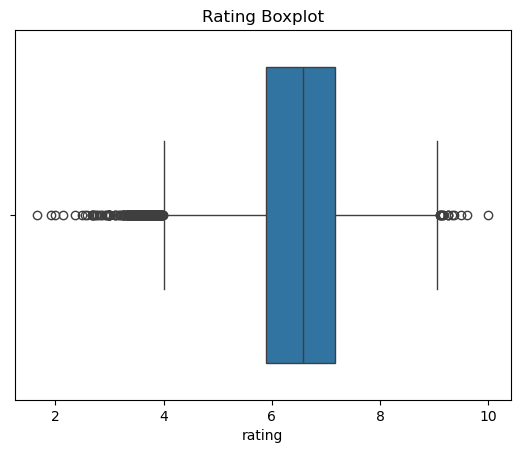

In [12]:
sns.boxplot(x=df['rating'])
plt.title('Rating Boxplot')
plt.show()

# Feature Extraction

In [13]:
# keep only the features we need for similarity
feat=df[['genre','rating','members','episodes','type']].copy()

In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

In [15]:
# split genres by comma and one-hot encode them
feat['genre']=feat['genre'].apply(lambda x:[g.strip() for g in str(x).split(',')])

In [16]:
mlb=MultiLabelBinarizer()
genre_enc=pd.DataFrame(mlb.fit_transform(feat['genre']),columns=mlb.classes_,index=feat.index)

In [17]:
feat=pd.concat([feat.drop('genre',axis=1),genre_enc],axis=1)
feat.head()

,rating,members,episodes,type,Action,Adventure,Cars,Comedy,Dementia,Demons,...,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri
0,9.37,200630,1.0,Movie,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,9.26,793665,64.0,TV,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9.25,114262,51.0,TV,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9.17,673572,24.0,TV,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,9.16,151266,51.0,TV,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# encode type column
feat=pd.get_dummies(feat,columns=['type'],prefix='type')
feat.head()

,rating,members,episodes,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,...,Vampire,Yaoi,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknown
0,9.37,200630,1.0,0,0,0,0,0,0,1,...,0,0,0,True,False,False,False,False,False,False
1,9.26,793665,64.0,1,1,0,0,0,0,1,...,0,0,0,False,False,False,False,False,True,False
2,9.25,114262,51.0,1,0,0,1,0,0,0,...,0,0,0,False,False,False,False,False,True,False
3,9.17,673572,24.0,0,0,0,0,0,0,0,...,0,0,0,False,False,False,False,False,True,False
4,9.16,151266,51.0,1,0,0,1,0,0,0,...,0,0,0,False,False,False,False,False,True,False


In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler=StandardScaler()
feat[['rating','members','episodes']]=scaler.fit_transform(feat[['rating','members','episodes']])
feat.head()

,rating,members,episodes,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,...,Vampire,Yaoi,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknown
0,2.845534,3.330241,-0.238677,0,0,0,0,0,0,1,...,0,0,0,True,False,False,False,False,False,False
1,2.737388,14.148406,1.123326,1,1,0,0,0,0,1,...,0,0,0,False,False,False,False,False,True,False
2,2.727556,1.754713,0.842278,1,0,0,1,0,0,0,...,0,0,0,False,False,False,False,False,True,False
3,2.648904,11.957666,0.258562,0,0,0,0,0,0,0,...,0,0,0,False,False,False,False,False,True,False
4,2.639073,2.429742,0.842278,1,0,0,1,0,0,0,...,0,0,0,False,False,False,False,False,True,False


# Recommendation System

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

In [22]:
sim=cosine_similarity(feat)
print("Similarity matrix shape:",sim.shape)

Similarity matrix shape: (12294, 12294)


In [23]:
def recommend(title,n=10,threshold=0.0):
    if title not in df['name'].values:
        print("Anime not found.")
        return
    idx=df[df['name']==title].index[0]
    scores=list(enumerate(sim[idx]))
    scores=sorted(scores,key=lambda x: x[1],reverse=True)
    scores=[s for s in scores if s[0]!=idx and s[1]>=threshold][:n]
    for i,score in scores:
        print(f"{df.loc[i, 'name']}  (similarity: {score:.4f})")

In [24]:
recommend('Steins;Gate')

Death Note  (similarity: 0.9854)
Code Geass: Hangyaku no Lelouch  (similarity: 0.9816)
Shingeki no Kyojin  (similarity: 0.9798)
Psycho-Pass  (similarity: 0.9791)
Durarara!!  (similarity: 0.9784)
Tengen Toppa Gurren Lagann  (similarity: 0.9781)
Toradora!  (similarity: 0.9775)
Angel Beats!  (similarity: 0.9763)
Mirai Nikki (TV)  (similarity: 0.9760)
Zankyou no Terror  (similarity: 0.9760)


In [25]:
# try different thresholds to see how list size changes
for t in [0.7, 0.8, 0.9, 0.95]:
    print(f"\nThreshold: {t}")
    recommend('Steins;Gate',n=20,threshold=t)


Threshold: 0.7
Death Note  (similarity: 0.9854)
Code Geass: Hangyaku no Lelouch  (similarity: 0.9816)
Shingeki no Kyojin  (similarity: 0.9798)
Psycho-Pass  (similarity: 0.9791)
Durarara!!  (similarity: 0.9784)
Tengen Toppa Gurren Lagann  (similarity: 0.9781)
Toradora!  (similarity: 0.9775)
Angel Beats!  (similarity: 0.9763)
Mirai Nikki (TV)  (similarity: 0.9760)
Zankyou no Terror  (similarity: 0.9760)
Deadman Wonderland  (similarity: 0.9757)
Fullmetal Alchemist: Brotherhood  (similarity: 0.9753)
Sword Art Online  (similarity: 0.9749)
Mahou Shoujo Madoka★Magica  (similarity: 0.9747)
Code Geass: Hangyaku no Lelouch R2  (similarity: 0.9745)
Guilty Crown  (similarity: 0.9727)
Another  (similarity: 0.9726)
Darker than Black: Kuro no Keiyakusha  (similarity: 0.9723)
Akame ga Kill!  (similarity: 0.9723)
Ano Hi Mita Hana no Namae wo Bokutachi wa Mada Shiranai.  (similarity: 0.9717)

Threshold: 0.8
Death Note  (similarity: 0.9854)
Code Geass: Hangyaku no Lelouch  (similarity: 0.9816)
Shingeki 

# Higher threshold means stricter similarity — fewer but more relevant results. Lower threshold gives more recommendations but some may not be closely related.

# Interview Questions

# Q1. Difference between user-based and item-based collaborative filtering?

# User-based: finds users similar to you and recommends what they liked.
# Item-based: finds items similar to what you already liked and recommends those.
# Item-based is more common in practice because user preferences change frequently but item similarity stays stable.

# Q2. What is collaborative filtering and how does it work?

# Collaborative filtering recommends items based on the behavior of many users — assuming people with similar taste will like similar things.
# It works in 3 steps:
# 1. Look at what you liked or rated.
# 2. Find users or items with similar patterns.
# 3. Recommend what those similar users liked or what similar items exist.